In [63]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from tqdm import tqdm

In [382]:
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
map = mapdf.to_numpy()[:, 0:6]
asic = map[0:64]
print(len(np.unique(asic[:, 5])))

1


In [356]:
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
map = mapdf.to_numpy()[:, 0:3]

# Create a xy angle and z table



def generateprimary(random = False, acollinearity = False, x = 0, y = 0, z = 0):
    if random:
        gentheta = np.random.uniform(0, 2*np.pi)
        genr = np.sqrt(np.random.uniform(0, 1)) * 160
        genz = np.random.uniform(-55, 55)
        x, y, z = genr * np.cos(gentheta), genr * np.sin(gentheta), genz
    while True:
        u = np.random.uniform(-1, 1)
        v = np.random.uniform(-1, 1)
        s = u**2 + v**2
        if s >= 1 or s == 0:
            continue
        factor = 2 * np.sqrt(1 - s)
        dx1 = u * factor
        dy1 = v * factor
        dz1 = 1 - 2 * s
        break
    dx2, dy2, dz2 = -dx1, -dy1, -dz1
    return x, y, z, dx1, dy1, dz1, dx2, dy2, dz2
    
def plotprimary(rp, ax, d=200):
    x, y, z = rp[0], rp[1], rp[2]
    dx1, dy1, dz1 = rp[3], rp[4], rp[5]
    dx2, dy2, dz2 = rp[6], rp[7], rp[8]

    ax.plot([x, x + dx1 * d], [y, y + dy1 * d], [z, z + dz1 * d], color='green', linewidth=2)
    ax.plot([x, x + dx2 * d], [y, y + dy2 * d], [z, z + dz2 * d], color='red', linewidth=2)

    for r in np.arange(20, d+1, 20):
        origin1 = np.array([x, y, z]) + r * np.array([dx1, dy1, dz1])
        direction1 = np.array([dx1, dy1, dz1])
        direction1 = direction1 / np.linalg.norm(direction1)
        if np.allclose(direction1, [0, 0, 1]):
            v1 = np.array([1, 0, 0])
        else:
            v1 = np.cross(direction1, [0, 0, 1])
            v1 = v1 / np.linalg.norm(v1)
        w1 = np.cross(direction1, v1)
        theta = np.linspace(0, 2 * np.pi, 100)
        circle1 = (origin1[:, None] +
                  (r / 10.0) * np.cos(theta) * v1[:, None] +
                  (r / 10.0) * np.sin(theta) * w1[:, None])
        ax.plot(circle1[0], circle1[1], circle1[2], color='green')
        origin2 = np.array([x, y, z]) + r * np.array([dx2, dy2, dz2])
        direction2 = np.array([dx2, dy2, dz2])
        direction2 = direction2 / np.linalg.norm(direction2)
        if np.allclose(direction2, [0, 0, 1]):
            v2 = np.array([1, 0, 0])
        else:
            v2 = np.cross(direction2, [0, 0, 1])
            v2 = v2 / np.linalg.norm(v2)
        w2 = np.cross(direction2, v2)
        circle2 = (origin2[:, None] +
                  (r / 10.0) * np.cos(theta) * v2[:, None] +
                  (r / 10.0) * np.sin(theta) * w2[:, None])
        ax.plot(circle2[0], circle2[1], circle2[2], color='red')

def plot_topring(ax):
    for i in range(topring.shape[0]):
        cx, cy = topring[i, 0], topring[i, 1]
        dx, dy = topring[i, 3], topring[i, 4]
        perp_unit = np.array([-dy, dx])
        corner_shifts = [
            -3/2 * perp_unit,
            3/2 * perp_unit,
            15 * np.array([dx, dy]) + 3/2 * perp_unit,
            15 * np.array([dx, dy]) - 3/2 * perp_unit,
            -3/2 * perp_unit # repeat to close
        ]
        corners = np.array([np.array([cx, cy]) + shift for shift in corner_shifts])
        ax.plot(corners[:,0], corners[:,1], 'b-')


# For checking if entrance intersection is valid
def check_valid_cylinder_intersection(x, y, z):
    if z < -53 or z > 53:
        return False
    if y < -140 or y > 140:
        return False 
    return True

# Geometry logic for intersection of a ray with a cylinder of radius r, direction d, from (x, y, z)
def solve_intersection(d, r, x, y, z):
    dx, dy, dz = d
    A = dx*dx + dy*dy
    B = 2 * (x * dx + y * dy)
    C = x*x + y*y - r*r
    discriminant = B*B - 4*A*C
    sqrt_disc = np.sqrt(discriminant)
    t1 = (-B - sqrt_disc)/(2*A)
    t2 = (-B + sqrt_disc)/(2*A)
    t = None
    if t1 >= 0 and t2 >= 0:
        t = min(t1, t2)
    elif t1 >= 0:
        t = t1
    elif t2 >= 0:
        t = t2
    return x+dx*t, y+dy*t, z+dz*t

def solve_intersections(rp, r1 = 165, r2 = 185):
    x, y, z = rp[0], rp[1], rp[2]
    dx1, dy1, dz1 = rp[3], rp[4], rp[5]
    dx2, dy2, dz2 = rp[6], rp[7], rp[8]
    results = []
    x_hit, y_hit, z_hit = solve_intersection((dx1, dy1, dz1), r1, x, y, z)
    if check_valid_cylinder_intersection(x_hit, y_hit, z_hit):
        results.append((x_hit, y_hit, z_hit))
    else:
        return None
    x_hit, y_hit, z_hit = solve_intersection((dx2, dy2, dz2), r1, x, y, z)
    if check_valid_cylinder_intersection(x_hit, y_hit, z_hit):
        if x_hit * results[0][0] > 0:
            return None
        results.append((x_hit, y_hit, z_hit))
    else:
        return None
    x_hit, y_hit, z_hit = solve_intersection((dx1, dy1, dz1), r2, x, y, z)
    results.append((x_hit, y_hit, z_hit))
    x_hit, y_hit, z_hit = solve_intersection((dx2, dy2, dz2), r2, x, y, z)
    results.append((x_hit, y_hit, z_hit))
    return results

def process_intersection(intersection):
    x, y, z = intersection
    if x < -160 or x > 160 or y < -160 or y > 160:
        return None
    return x, y, z


4
(np.float64(47.30919488363473), np.float64(-94.48887343430253), -6.364291987795518, np.float64(-0.8836727297520471), np.float64(0.4613409660281939), 0.07929072932404269, np.float64(0.8836727297520471), np.float64(-0.4613409660281939), -0.07929072932404269)
[(np.float64(-164.2274184654808), np.float64(15.948511659833812), np.float64(12.616595151152133)), (np.float64(106.96415889253225), np.float64(-125.63307173038916), np.float64(-11.717049230165363)), (np.float64(-183.18564471752427), np.float64(25.846074545759834), np.float64(14.317690517800518)), (np.float64(125.92238514457571), np.float64(-135.53063461631518), np.float64(-13.41814459681375))]


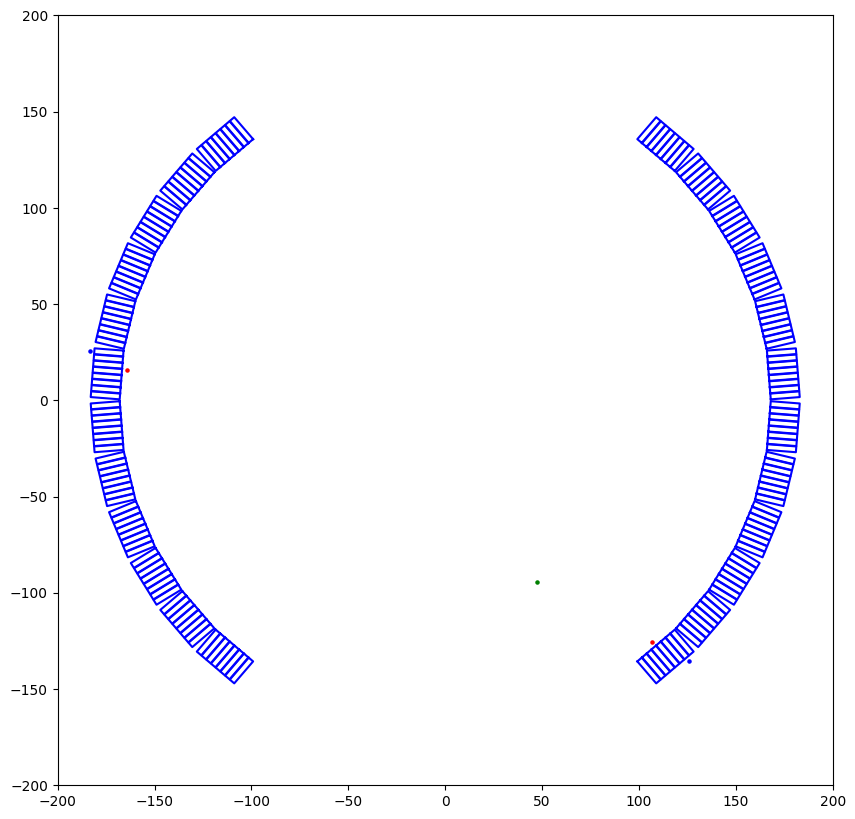

In [376]:
intersections = None
loopcount = 0 
while intersections is None:
    rp = generateprimary(random = True)
    intersections = solve_intersections(rp)
    loopcount += 1
print(loopcount)
print(rp)
print(intersections)
plt.figure(figsize = (10, 10))
plt.xlim(-200, 200)
plt.ylim(-200, 200)
plt.scatter(rp[0], rp[1], color = 'green', s = 5)
plt.scatter([intersections[0][0], intersections[1][0]], [intersections[0][1], intersections[1][1]], color = 'red', s = 5)
plt.scatter([intersections[2][0], intersections[3][0]], [intersections[2][1], intersections[3][1]], color = 'blue', s = 5)
plot_topring(plt.gca())
plt.show()

100%|██████████| 10000000/10000000 [01:21<00:00, 123342.72it/s]


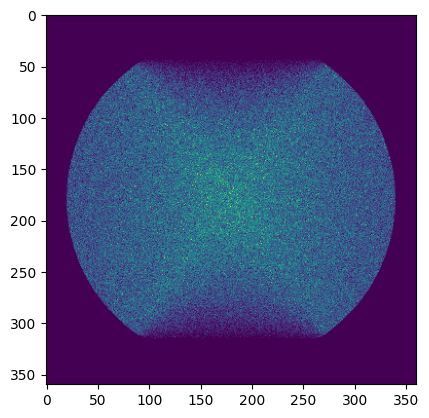

In [ ]:
genimg = np.zeros((360, 360, 110), dtype = np.int16)
for i in tqdm(range(10000000)):
    rp = generateprimary(random = True)
    intersections = solve_intersections(rp)
    if intersections is not None:
        x, y, z = rp[0], rp[1], rp[2]
        genimg[int(y + 180), int(x + 180), int(z + 55)] += 1


In [303]:
print(np.sum(genimg))

523297


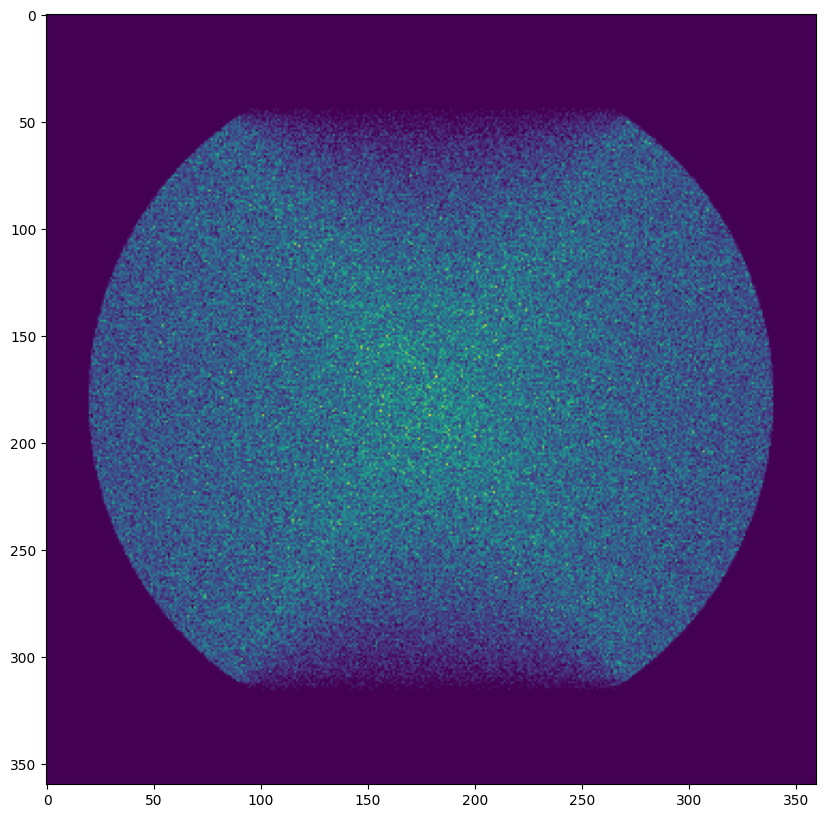

In [302]:
plt.figure(figsize = (10, 10))
plt.imshow(np.sum(genimg, axis = 2))
plt.show()

In [62]:
count = 0
for x in np.arange(-160, 160+1, 1):
    for y in np.arange(-160, 160+1, 1):
        if x**2 + y**2 > 160**2:
            continue
        for z in np.arange(-55, 55+1, 1):
            count += 1
print(count)

8922291


-96.12 0.8 -75.69 -0.41 0.81 -0.42 0.41 -0.81 0.42


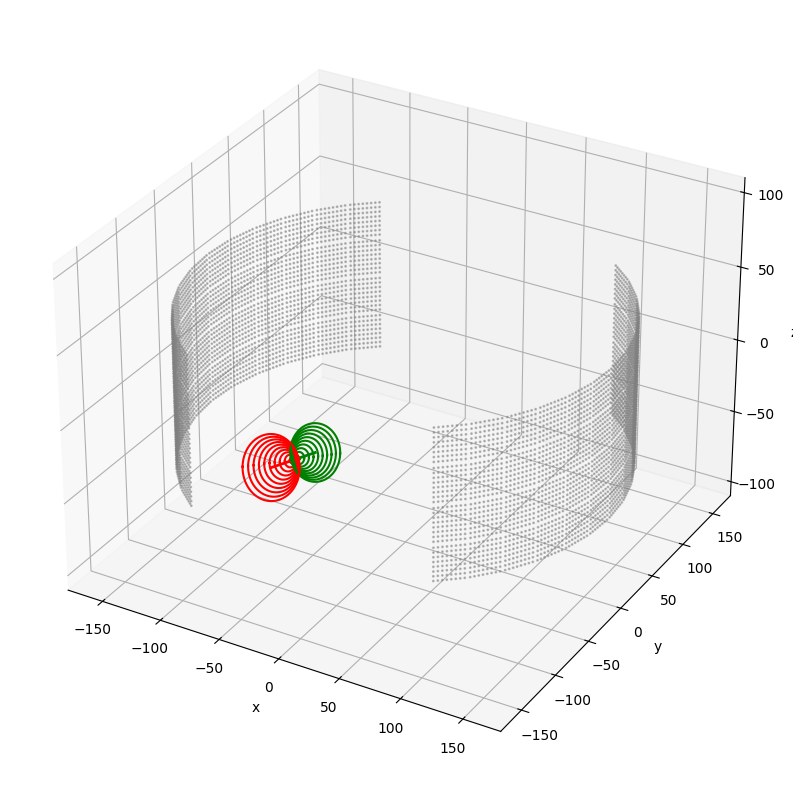

In [56]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(map[:,0], map[:,1], map[:,2], marker='o', color = 'gray', alpha = 0.5, s=1)

rp = generateprimary(random = True)
print(round(rp[0], 2), round(rp[1], 2), round(rp[2], 2), round(rp[3], 2), round(rp[4], 2), round(rp[5], 2), round(rp[6], 2), round(rp[7], 2), round(rp[8], 2))
plotprimary(rp, ax)
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_zlim(-110, 110)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_zticks([-100, -50, 0, 50, 100])
plt.show()